# 👥 Notebook 4 — Customer Analytics (Warehouse-Driven)
**Project:** Shopify E-Commerce Analytics Data Warehouse  
**Layer:** Analytics — Customer Intelligence  
**Purpose:** RFM segmentation, CLV calculation, cohort retention, Pareto 80/20 analysis.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#0f1117','axes.facecolor':'#1a1d2e',
    'axes.edgecolor':'#2e3250','axes.labelcolor':'#c9d1d9',
    'xtick.color':'#8b949e','ytick.color':'#8b949e',
    'text.color':'#c9d1d9','grid.color':'#2e3250',
    'grid.linestyle':'--','grid.alpha':0.5,
    'font.family':'monospace','axes.titlesize':13,'axes.titleweight':'bold',
})
ACCENT,ACCENT2,ACCENT3,RED,YELLOW='#4fc3f7','#a78bfa','#34d399','#f87171','#fbbf24'
SEG_COLORS = {
    'Champions':'#fbbf24','Loyal Customers':'#34d399',
    'Potential Loyalists':'#4fc3f7','Promising':'#a78bfa',
    'At Risk':'#f97316','Lost Customers':'#f87171',
    'Hibernating':'#94a3b8','Need Attention':'#e879f9'
}

fact  = pd.read_csv('warehouse/fact_sales.csv')
dcust = pd.read_csv('warehouse/dim_customer.csv')
ddate = pd.read_csv('warehouse/dim_date.csv')

fact['order_date'] = pd.to_datetime(fact['date_key'].astype(str), format='%Y%m%d')
SNAPSHOT = fact['order_date'].max() + timedelta(days=1)
print(f"✅ Data loaded. Snapshot date: {SNAPSHOT.date()}")

✅ Data loaded. Snapshot date: 2025-06-19


## 1. RFM Calculation

In [2]:
# ── Recency, Frequency, Monetary per customer ─────────────────────
rfm = fact.groupby('customer_key').agg(
    last_order_date = ('order_date','max'),
    frequency       = ('order_id','nunique'),
    monetary        = ('revenue','sum')
).reset_index()

rfm['recency_days'] = (SNAPSHOT - rfm['last_order_date']).dt.days

# Score 1-5 (5=best)
rfm['r_score'] = pd.qcut(rfm['recency_days'].rank(method='first'),  5, labels=[5,4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'),     5, labels=[1,2,3,4,5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'),      5, labels=[1,2,3,4,5]).astype(int)

rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']
rfm['monetary']  = rfm['monetary'].round(2)

print(f"RFM table: {rfm.shape[0]:,} customers")
rfm[['customer_key','recency_days','frequency','monetary','r_score','f_score','m_score','rfm_score']].head(5)

RFM table: 31,154 customers


,customer_key,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_score
0,1,495,1,798.90,2,1,1,4
1,2,52,5,25517.78,5,5,5,15
2,3,373,2,2943.12,3,3,2,8
3,4,127,2,6127.37,4,3,2,9
4,5,779,1,11391.45,1,1,4,6


## 2. RFM Segmentation

In [3]:
def assign_segment(row):
    r,f,m = row['r_score'], row['f_score'], row['m_score']
    if r>=4 and f>=4 and m>=4:           return 'Champions'
    elif r>=3 and f>=3 and m>=3:         return 'Loyal Customers'
    elif r>=4 and f<=2:                  return 'Potential Loyalists'
    elif r>=3 and f>=3 and m<=2:         return 'Promising'
    elif r<=2 and f>=3 and m>=3:         return 'At Risk'
    elif r==1 and f>=2:                  return 'Lost Customers'
    elif r<=2 and f<=2 and m<=2:         return 'Hibernating'
    else:                                return 'Need Attention'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

seg_summary = rfm.groupby('segment').agg(
    customers=('customer_key','count'),
    avg_recency=('recency_days','mean'),
    avg_frequency=('frequency','mean'),
    avg_monetary=('monetary','mean'),
    total_revenue=('monetary','sum')
).reset_index().sort_values('total_revenue', ascending=False)

seg_summary['revenue_pct'] = (seg_summary['total_revenue']/seg_summary['total_revenue'].sum()*100).round(2)
seg_summary['cust_pct']    = (seg_summary['customers']/seg_summary['customers'].sum()*100).round(2)

print("RFM SEGMENT SUMMARY")
print("=" * 80)
print(seg_summary.to_string(index=False))

RFM SEGMENT SUMMARY
            segment  customers  avg_recency  avg_frequency  avg_monetary  total_revenue  revenue_pct  cust_pct
          Champions       4700    98.662766       3.300638  20244.406453    95148710.33        30.47     15.09
    Loyal Customers       6143   207.032069       2.466873  13598.492626    83535540.20        26.75     19.72
            At Risk       3760   543.487500       2.317819  14229.312511    53502215.04        17.14     12.07
     Need Attention       4641   439.720103       1.186813   6771.271745    31425472.17        10.06     14.90
Potential Loyalists       3159   111.789807       1.000000   5174.964359    16347712.41         5.24     10.14
     Lost Customers       2791   735.640272       1.144393   4811.874647    13429942.14         4.30      8.96
          Promising       2601   170.205690       2.075356   3846.224756    10004030.59         3.20      8.35
        Hibernating       3359   592.348020       1.000000   2630.234418     8834957.41     

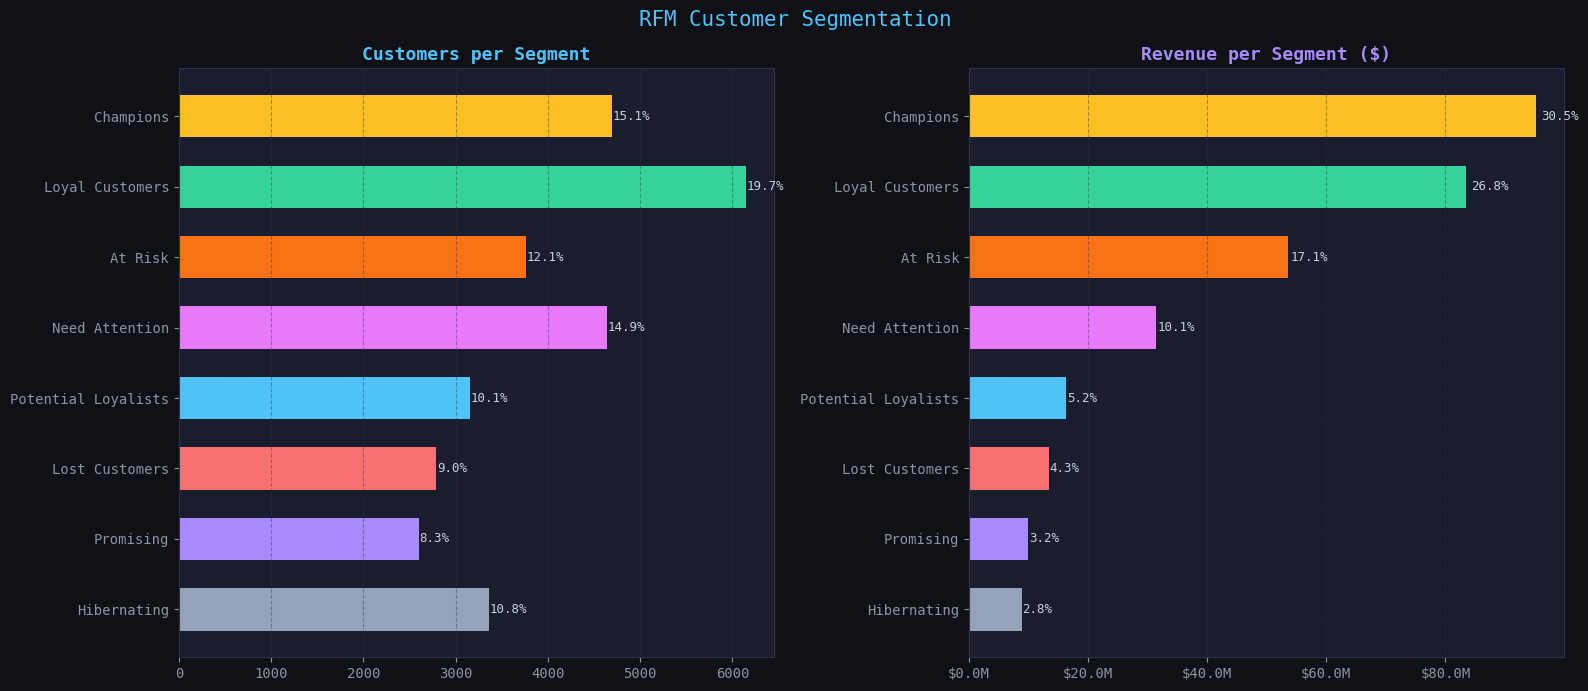

In [4]:
# ── Visualize segments ────────────────────────────────────────────
fig, axes = plt.subplots(1,2, figsize=(16,7))
fig.suptitle("RFM Customer Segmentation", fontsize=15, color=ACCENT)

seg_colors = [SEG_COLORS.get(s, ACCENT) for s in seg_summary['segment']]
axes[0].barh(seg_summary['segment'], seg_summary['customers'],
             color=seg_colors, edgecolor='none', height=0.6)
axes[0].set_title("Customers per Segment", color=ACCENT)
axes[0].invert_yaxis(); axes[0].grid(True, axis='x', alpha=0.4)
for i, (v, p) in enumerate(zip(seg_summary['customers'], seg_summary['cust_pct'])):
    axes[0].text(v+5, i, f'{p:.1f}%', va='center', fontsize=9)

axes[1].barh(seg_summary['segment'], seg_summary['total_revenue'],
             color=seg_colors, edgecolor='none', height=0.6)
axes[1].set_title("Revenue per Segment ($)", color=ACCENT2)
axes[1].invert_yaxis(); axes[1].grid(True, axis='x', alpha=0.4)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M'))
for i, (v, p) in enumerate(zip(seg_summary['total_revenue'], seg_summary['revenue_pct'])):
    axes[1].text(v*1.01, i, f'{p:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Customer Lifetime Value (CLV)

In [5]:
clv = fact.groupby('customer_key').agg(
    total_orders   = ('order_id','nunique'),
    total_revenue  = ('revenue','sum'),
    total_profit   = ('profit','sum'),
    first_order    = ('order_date','min'),
    last_order     = ('order_date','max'),
    avg_order_val  = ('revenue','mean'),
).reset_index()

clv['lifespan_days']   = (clv['last_order'] - clv['first_order']).dt.days.clip(lower=1)
clv['annual_freq']     = (clv['total_orders'] / clv['lifespan_days'] * 365).clip(lower=1)
clv['clv_3yr_proj']    = (clv['avg_order_val'] * clv['annual_freq'] * 3).round(2)
clv['historical_clv']  = clv['total_revenue'].round(2)

clv['clv_tier'] = pd.cut(clv['historical_clv'],
                         bins=[0,1000,5000,10000,np.inf],
                         labels=['Bronze','Silver','Gold','Platinum'])

tier_summary = clv.groupby('clv_tier', observed=True).agg(
    customers=('customer_key','count'),
    total_revenue=('historical_clv','sum'),
    avg_clv=('historical_clv','mean')
).reset_index()
tier_summary['rev_pct'] = (tier_summary['total_revenue']/tier_summary['total_revenue'].sum()*100).round(2)

print("CLV TIER DISTRIBUTION")
print(tier_summary.to_string(index=False))

print(f"\n  Top 10 customers account for "
      f"${clv.nlargest(10,'historical_clv')['historical_clv'].sum():,.0f} in revenue")

CLV TIER DISTRIBUTION
clv_tier  customers  total_revenue      avg_clv  rev_pct
  Bronze       1942     1035841.96   533.389269     0.33
  Silver       8456    24841267.66  2937.709042     7.96
    Gold       8026    59043095.99  7356.478444    18.91
Platinum      12730   227308374.68 17856.117414    72.80

  Top 10 customers account for $609,470 in revenue


## 4. Pareto 80/20 Analysis

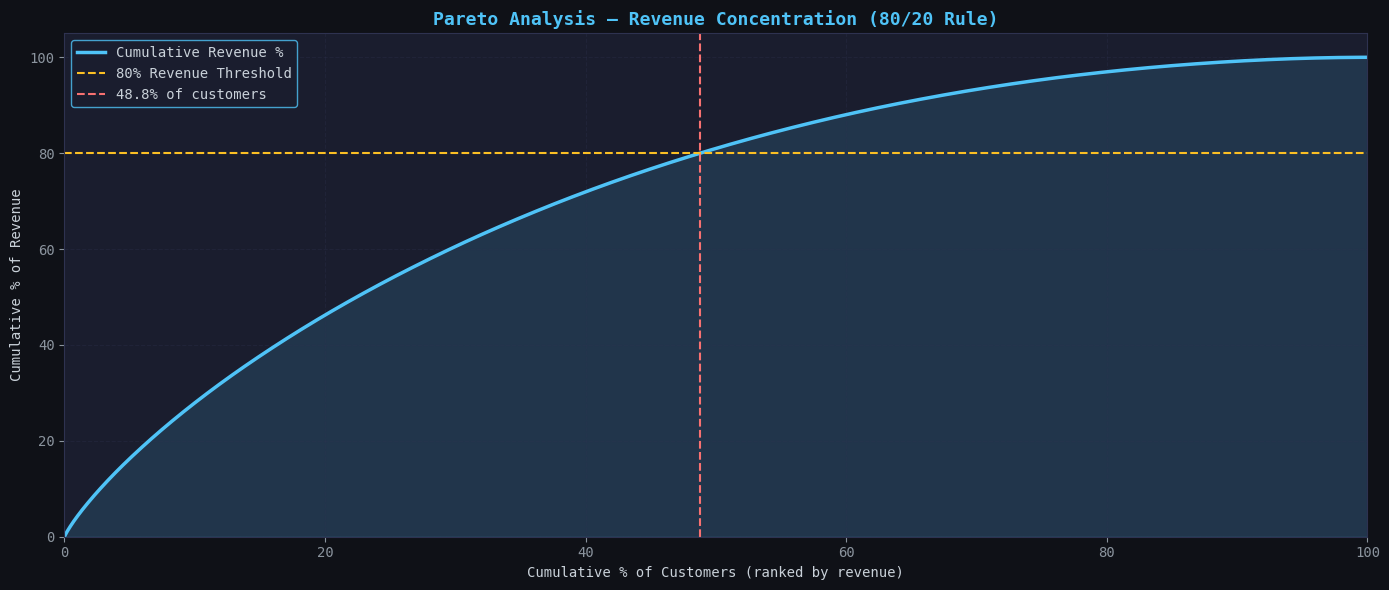


📌 INSIGHT: Top 48.8% of customers generate 80% of revenue
📌 RECOMMENDATION: Protect Champions and Loyal Customers with VIP programs & early access.


In [6]:
clv_sorted = clv.sort_values('historical_clv', ascending=False).reset_index(drop=True)
clv_sorted['cum_revenue'] = clv_sorted['historical_clv'].cumsum()
clv_sorted['cum_rev_pct'] = clv_sorted['cum_revenue'] / clv_sorted['historical_clv'].sum() * 100
clv_sorted['cust_pct']    = (clv_sorted.index+1) / len(clv_sorted) * 100

idx_80 = (clv_sorted['cum_rev_pct'] >= 80).idxmax()
pct_customers_80 = clv_sorted.loc[idx_80, 'cust_pct']

fig, ax = plt.subplots(figsize=(14,6))
ax.plot(clv_sorted['cust_pct'], clv_sorted['cum_rev_pct'],
        color=ACCENT, linewidth=2.5, label='Cumulative Revenue %')
ax.fill_between(clv_sorted['cust_pct'], clv_sorted['cum_rev_pct'], alpha=0.15, color=ACCENT)
ax.axhline(80, color=YELLOW, linestyle='--', linewidth=1.5, label='80% Revenue Threshold')
ax.axvline(pct_customers_80, color=RED, linestyle='--', linewidth=1.5,
           label=f'{pct_customers_80:.1f}% of customers')
ax.set_xlabel("Cumulative % of Customers (ranked by revenue)")
ax.set_ylabel("Cumulative % of Revenue")
ax.set_title("Pareto Analysis — Revenue Concentration (80/20 Rule)", color=ACCENT)
ax.legend(facecolor='#1a1d2e', edgecolor=ACCENT, labelcolor='#c9d1d9')
ax.grid(True, alpha=0.3)
ax.set_xlim(0,100); ax.set_ylim(0,105)
plt.tight_layout()
plt.show()

print(f"\n📌 INSIGHT: Top {pct_customers_80:.1f}% of customers generate 80% of revenue")
print("📌 RECOMMENDATION: Protect Champions and Loyal Customers with VIP programs & early access.")

## 5. Cohort Retention Analysis

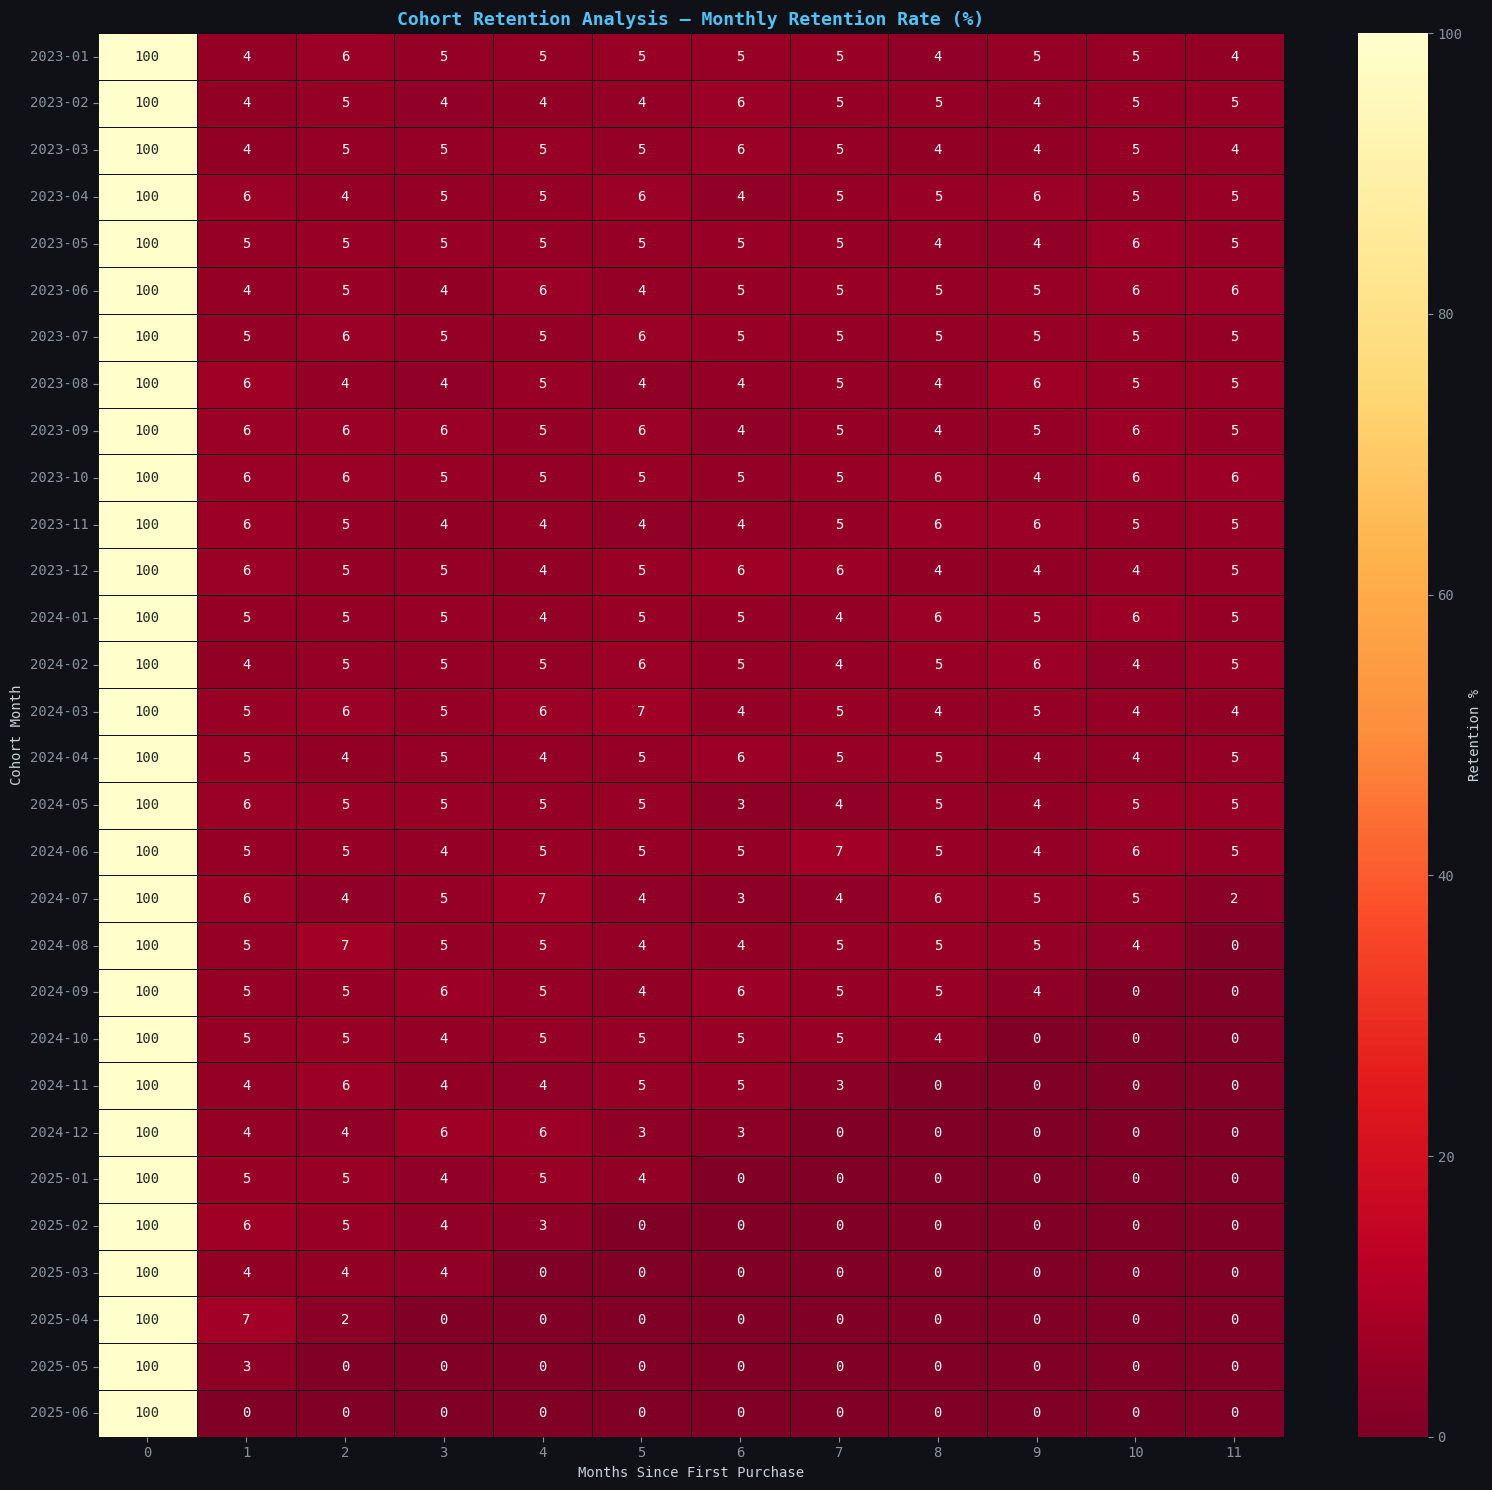


📌 INSIGHT: Retention drops sharply after month 1 — acquisition is strong but retention is weak.
📌 RECOMMENDATION: Implement post-purchase email sequence to convert one-time buyers.


In [7]:
fact_coh = fact.copy()
fact_coh['order_month'] = fact_coh['order_date'].dt.to_period('M')

cohort_start = fact_coh.groupby('customer_key')['order_month'].min().rename('cohort_month')
fact_coh = fact_coh.join(cohort_start, on='customer_key')
fact_coh['period'] = (fact_coh['order_month'] - fact_coh['cohort_month']).apply(lambda x: x.n)

cohort_table = fact_coh.groupby(['cohort_month','period'])['customer_key'].nunique().unstack(fill_value=0)
cohort_pct   = cohort_table.divide(cohort_table[0], axis=0).round(3) * 100

# Plot first 12 periods
plot_data = cohort_pct.iloc[:, :12]

fig, ax = plt.subplots(figsize=(16, max(6, len(plot_data)*0.5)))
sns.heatmap(
    plot_data, annot=True, fmt='.0f', cmap='YlOrRd_r',
    linewidths=0.5, linecolor='#0f1117',
    cbar_kws={'label':'Retention %'},
    ax=ax
)
ax.set_title("Cohort Retention Analysis — Monthly Retention Rate (%)", color=ACCENT, fontsize=13)
ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Cohort Month")
ax.tick_params(axis='x', colors='#8b949e')
ax.tick_params(axis='y', colors='#8b949e', rotation=0)
plt.tight_layout()
plt.show()
print("\n📌 INSIGHT: Retention drops sharply after month 1 — acquisition is strong but retention is weak.")
print("📌 RECOMMENDATION: Implement post-purchase email sequence to convert one-time buyers.")

## 6. Repeat Purchase Behavior

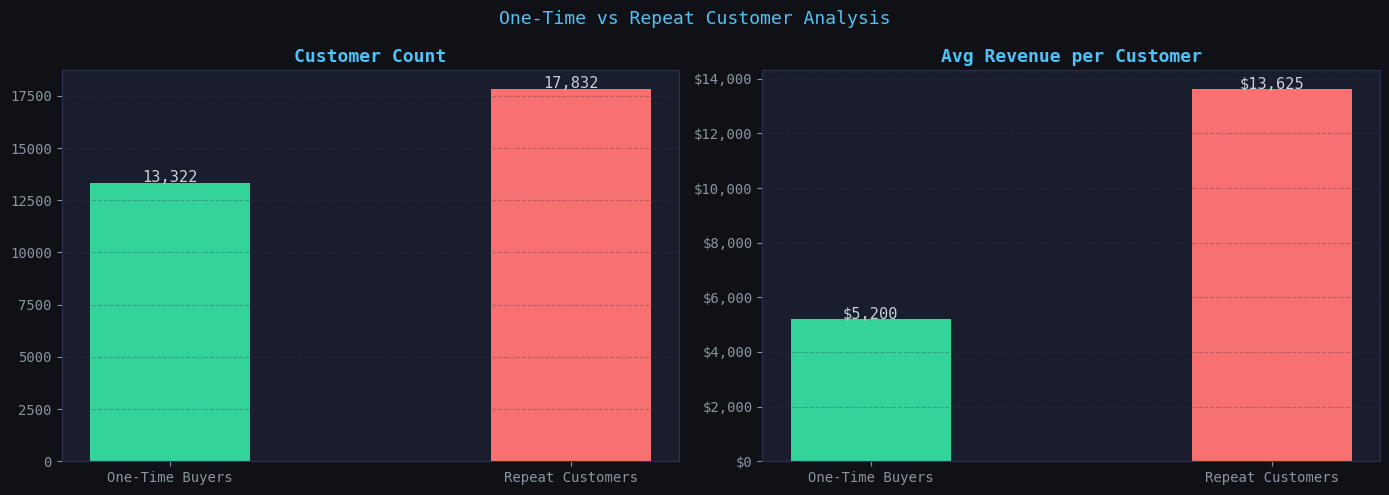


📌 INSIGHT: Repeat customers generate significantly higher average revenue.
📌 RECOMMENDATION: Focus first-purchase experience to maximize conversion to repeat buyer.


In [8]:
repeat = clv.copy()
repeat['is_repeat'] = repeat['total_orders'] > 1
rep_sum = repeat.groupby('is_repeat').agg(
    customers=('customer_key','count'),
    total_revenue=('historical_clv','sum'),
    avg_revenue=('historical_clv','mean'),
    avg_orders=('total_orders','mean'),
).reset_index()
rep_sum['label'] = rep_sum['is_repeat'].map({True:'Repeat Customers', False:'One-Time Buyers'})

fig, axes = plt.subplots(1,2, figsize=(14,5))
fig.suptitle("One-Time vs Repeat Customer Analysis", fontsize=13, color=ACCENT)

colors = [ACCENT3, RED]
axes[0].bar(rep_sum['label'], rep_sum['customers'], color=colors, edgecolor='none', width=0.4)
axes[0].set_title("Customer Count", color=ACCENT)
for i, v in enumerate(rep_sum['customers']):
    axes[0].text(i, v+50, f'{v:,}', ha='center', fontsize=11)

axes[1].bar(rep_sum['label'], rep_sum['avg_revenue'], color=colors, edgecolor='none', width=0.4)
axes[1].set_title("Avg Revenue per Customer", color=ACCENT)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))
for i, v in enumerate(rep_sum['avg_revenue']):
    axes[1].text(i, v+20, f'${v:,.0f}', ha='center', fontsize=11)

for ax in axes: ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("\n📌 INSIGHT: Repeat customers generate significantly higher average revenue.")
print("📌 RECOMMENDATION: Focus first-purchase experience to maximize conversion to repeat buyer.")